<a href="https://colab.research.google.com/github/ciril7/AI-ML-Internship/blob/main/Day%208/News_Article_Summarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

path = kagglehub.dataset_download("sbhatti/news-summarization")

print(path)

100%|██████████| 1.37G/1.37G [01:06<00:00, 22.1MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/sbhatti/news-summarization/versions/1


In [3]:
import os

for root, dirs, files in os.walk(path):
    print("Files:")
    for file in files:
        print(file)

Files:
data.csv


In [4]:
import pandas as pd
import os

file_path = os.path.join(path, "data.csv")

df = pd.read_csv(file_path)

print(df.head())
print(df.columns)
print(df.shape)

   Unnamed: 0                                        ID  \
0           0  f49ee725a0360aa6881ed1f7999cc531885dd06a   
1           1  808fe317a53fbd3130c9b7563341a7eea6d15e94   
2           2  98fd67bd343e58bc4e275bbb5a4ea454ec827c0d   
3           3  e12b5bd7056287049d9ec98e41dbb287bd19a981   
4           4  b83e8bcfcd51419849160e789b6658b21a9aedcd   

                                             Content  \
0  New York police are concerned drones could bec...   
1  By . Ryan Lipman . Perhaps Australian porn sta...   
2  This was, Sergio Garcia conceded, much like be...   
3  An Ebola outbreak that began in Guinea four mo...   
4  By . Associated Press and Daily Mail Reporter ...   

                                             Summary         Dataset  
0  Police have investigated criminals who have ri...  CNN/Daily Mail  
1  Porn star Angela White secretly filmed sex act...  CNN/Daily Mail  
2  American draws inspiration from fellow country...  CNN/Daily Mail  
3  World Health Organisa

In [5]:
df = df.sample(1000, random_state=42)

In [6]:
df = df[['Content', 'Summary']].dropna()
df = df.sample(1000, random_state=42)

In [7]:
!pip install transformers datasets evaluate rouge_score sentencepiece accelerate -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 927.6 kB/s eta 0:00:00


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [9]:
df = df.dropna()

print(df.shape)

(1000, 2)


In [10]:
print(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 497181 to 171724
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Content  1000 non-null   object
 1   Summary  1000 non-null   object
dtypes: object(2)
memory usage: 23.4+ KB
None


,Content,Summary
497181,It marked a fourth straight win for the German...,When Nico Rosberg won the Russian Grand Prix i...
727537,"By . Ian Garland . PUBLISHED: . 14:24 EST, 15 ...",Mueen-Uddin allegedly linked to crimes during ...
497677,Media playback is not supported on this device...,British number one Johanna Konta says she is i...
94261,A homeless charity has warned of a 'crisis' af...,Number of new homes built in England drops 6 p...
399082,By . Ryan Gorman . and Michael Zennie . A 35-y...,Father was in the midst of a messy custody dis...


In [11]:
df["article_length"] = df["Content"].apply(lambda x: len(str(x).split()))

df["summary_length"] = df["Summary"].apply(lambda x: len(str(x).split()))

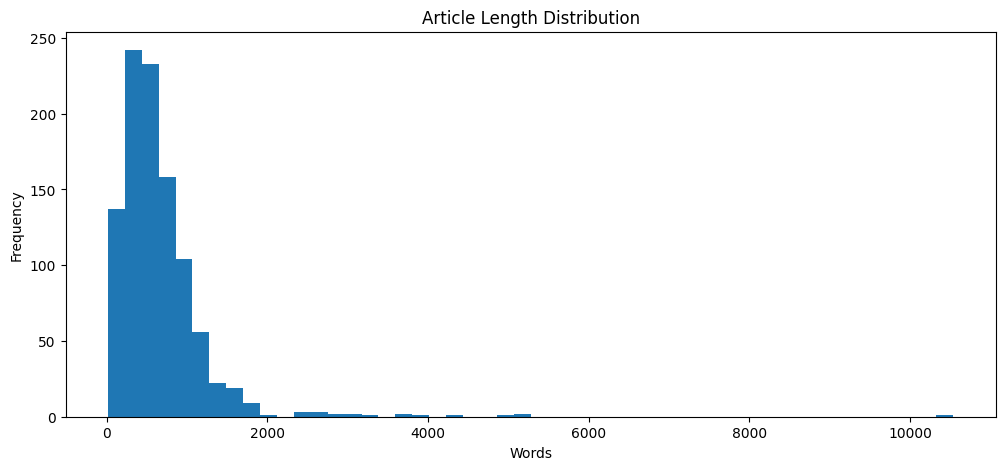

In [12]:
plt.figure(figsize=(12,5))

plt.hist(df["article_length"], bins=50)

plt.title("Article Length Distribution")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

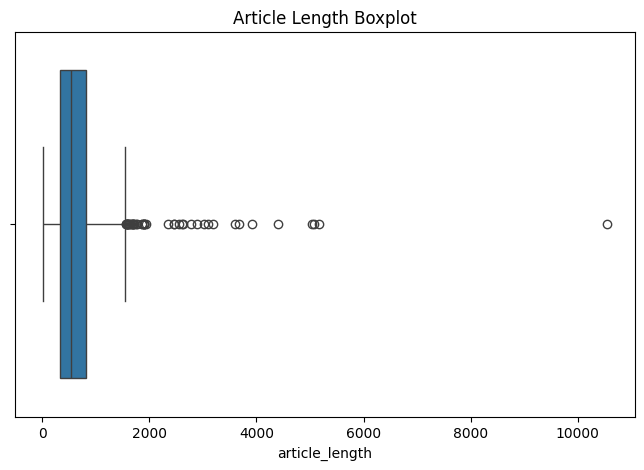

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["article_length"])

plt.title("Article Length Boxplot")

plt.show()

In [14]:
import re

def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r'\s+', ' ', text)

    text = re.sub(r'[^a-zA-Z0-9.,!? ]', '', text)

    return text.strip()

In [15]:
df["Content"] = df["Content"].apply(clean_text)

df["Summary"] = df["Summary"].apply(clean_text)

In [16]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

In [17]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

In [18]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 700
Validation: 150
Test: 150


In [31]:
train_df = train_df.reset_index(drop=True)

val_df = val_df.reset_index(drop=True)

test_df = test_df.reset_index(drop=True)

In [32]:
train_df.to_csv("/content/train.csv", index=False)

val_df.to_csv("/content/validation.csv", index=False)

test_df.to_csv("/content/test.csv", index=False)

In [21]:
!pip install transformers datasets sentencepiece accelerate evaluate rouge_score -q

In [22]:
from datasets import Dataset
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    TrainingArguments,
    Trainer
)

In [23]:
import pandas as pd

train_df = pd.read_csv("/content/train.csv")
val_df = pd.read_csv("/content/validation.csv")
test_df = pd.read_csv("/content/test.csv")

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(700, 4)
(150, 4)
(150, 4)


In [24]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [25]:
model_name = "t5-small"

tokenizer = T5Tokenizer.from_pretrained(model_name)

model = T5ForConditionalGeneration.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [26]:
max_input_length = 512
max_target_length = 128

def preprocess_function(examples):

    inputs = [
        "summarize: " + doc
        for doc in examples["Content"]
    ]

    model_inputs = tokenizer(
        inputs,
        max_length=max_input_length,
        truncation=True,
        padding="max_length"
    )

    labels = tokenizer(
        examples["Summary"],
        max_length=max_target_length,
        truncation=True,
        padding="max_length"
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

In [27]:
tokenized_train = train_dataset.map(
    preprocess_function,
    batched=True
)

tokenized_val = val_dataset.map(
    preprocess_function,
    batched=True
)

tokenized_test = test_dataset.map(
    preprocess_function,
    batched=True
)

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

In [28]:
training_args = TrainingArguments(
    output_dir="./t5_news_model",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    save_total_limit=2,
    logging_steps=50
)

In [29]:
num_train_epochs=3

In [30]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val
)

In [33]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,8.510742,5.882064


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=88, training_loss=7.404595981944691, metrics={'train_runtime': 2051.9681, 'train_samples_per_second': 0.341, 'train_steps_per_second': 0.043, 'total_flos': 94739261030400.0, 'train_loss': 7.404595981944691, 'epoch': 1.0})

In [34]:
model.save_pretrained(
    "/content/fine_tuned_t5"
)

tokenizer.save_pretrained(
    "/content/fine_tuned_t5"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/fine_tuned_t5/tokenizer_config.json',
 '/content/fine_tuned_t5/tokenizer.json')

In [35]:
sample_article = test_df.iloc[0]["Content"]

inputs = tokenizer(
    "summarize: " + sample_article,
    return_tensors="pt",
    max_length=512,
    truncation=True
)

summary_ids = model.generate(
    inputs["input_ids"],
    max_length=128,
    min_length=30,
    num_beams=4,
    early_stopping=True
)

generated_summary = tokenizer.decode(
    summary_ids[0],
    skip_special_tokens=True
)

print("ORIGINAL ARTICLE:")
print(sample_article[:1000])

print("\nGENERATED SUMMARY:")
print(generated_summary)

ORIGINAL ARTICLE:
with more than 3,000 listed places of worship in wales, the welsh government said many were under threat. new activities will be encouraged to save the buildings, either as religious centres or with an alternative purpose. deputy culture minister ken skates, visiting st giles parish church in wrexham, said it was always a shame to see cherished buildings neglected. the grade i listed church hosts community groups and religious services, and received welsh government funding to restore its tower.

GENERATED SUMMARY:
welsh government says many are under threat. new activities will be encouraged to save the buildings. the grade i listed church hosts community groups and religious services.


In [38]:
new_article = """
 Messi Shines in Historic Sixth World Cup Appearance
On a day featuring goals from Kylian Mbappe and Erling Haaland, Lionel Messi still stole the headlines. The 38-year-old scored a spectacular hat-trick to lead Argentina to a 3-0 victory over Algeria in Kansas City, netting his record-equalling 16th World Cup goal.

The match marked a historic milestone: Messi became the first man to play in six World Cups, debuting exactly 20 years ago at Germany 2006. It was also his 200th appearance for Argentina. Despite a brief, unpunished first-half scare where his studs caught Aissa Mandi’s heel, Messi remained unstoppable.

"Everything I'm experiencing now is a bonus," Messi said after the match, thanking the fans and praising his united squad.

Argentina coach Lionel Scaloni added: "I don't have the words to describe Messi. For 20 years, he's inspired everyone who watches him play."
"""

inputs = tokenizer(
    "summarize: " + new_article,
    return_tensors="pt",
    max_length=512,
    truncation=True
)

summary_ids = model.generate(
    inputs["input_ids"],
    max_length=128,
    min_length=30,
    num_beams=4
)

summary = tokenizer.decode(
    summary_ids[0],
    skip_special_tokens=True
)

print("SUMMARY:\n")
print(summary)

SUMMARY:

Lionel Messi scores hat-trick to lead argentina to 3-0 victory over Algeria. the 38-year-old became the first man to play in six world cups. it was also his 200th appearance for argentina.


**EVALUATION OF THE SUMMARY**

In [39]:
!pip install evaluate rouge_score -q

In [40]:
import evaluate

rouge = evaluate.load("rouge")

In [41]:
predictions = []
references = []

for i in range(50):   # evaluate on first 50 test samples

    article = test_df.iloc[i]["Content"]
    reference = test_df.iloc[i]["Summary"]

    inputs = tokenizer(
        "summarize: " + article,
        return_tensors="pt",
        max_length=512,
        truncation=True
    )

    summary_ids = model.generate(
        inputs["input_ids"],
        max_length=128
    )

    prediction = tokenizer.decode(
        summary_ids[0],
        skip_special_tokens=True
    )

    predictions.append(prediction)
    references.append(reference)

results = rouge.compute(
    predictions=predictions,
    references=references
)

print(results)

{'rouge1': np.float64(0.29475067989795045), 'rouge2': np.float64(0.10103431321116646), 'rougeL': np.float64(0.21346962034973818), 'rougeLsum': np.float64(0.2131392518430907)}


**COMPARING ORIGINAL vs HUMAN SUMMARY vs MODEL SUMMARY**

In [42]:
 idx = 5

article = test_df.iloc[idx]["Content"]
human_summary = test_df.iloc[idx]["Summary"]

inputs = tokenizer(
    "summarize: " + article,
    return_tensors="pt",
    max_length=512,
    truncation=True
)

summary_ids = model.generate(
    inputs["input_ids"],
    max_length=128
)

generated_summary = tokenizer.decode(
    summary_ids[0],
    skip_special_tokens=True
)

print("ARTICLE:\n")
print(article[:1200])

print("\n" + "="*80)

print("\nHUMAN SUMMARY:\n")
print(human_summary)

print("\n" + "="*80)

print("\nMODEL SUMMARY:\n")
print(generated_summary)

ARTICLE:

consular officials can now ask for social media usernames going back five years via a new questionnaire. it also allows authorities to request email addresses, phone numbers and 15 years of biographical information. this can be requested when more rigorous national security security vetting is needed, a state department official told reuters. according to reports, the state department expects that about 0.5 of visa applicants will be given the questionnaire. critics have argued that the checks could lead to extended, fruitless lines of inquiry or the collection of personal information not relevant to security checks. providing the information is voluntary, though the questionnaire informs applicants that individuals who ... do not provide all the requested information may be denied a us visa. a proposal to request social media identifiers for travellers using the visa waiver program was put forward by us customs and border protection cbp last year. this came into force for so